# Advanced baseline processing

This notebook demonstrates how one can remove a baseline from the data. IMPORTANT: It requires that the resonance is much narrower than the changes in the baseline and that a sufficiently large part of the baseline is recorded.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
%matplotlib inline

## 1. Flat Baseline

First, we generate some fake data which we can fit later:

In [2]:
from resonator_tools import circuit
fr = 7e9  #resonance frequency in Hz
Qi = 200e3
Qc = 300e3
freq = np.linspace(fr-5e6, fr+5e6, 5000)
port1 = circuit.reflection_port()  #define a reflection port
noise = np.random.normal(loc=1.0,scale=0.01,size=(len(freq),))
S11 = noise * port1._S11_directrefl(freq,fr=fr,Ql=Qi*Qc/(Qc+Qi),Qc=Qc,a=1.,alpha=0.,delay=.0)
port1.add_data(freq,S11)

Let's plot the data:

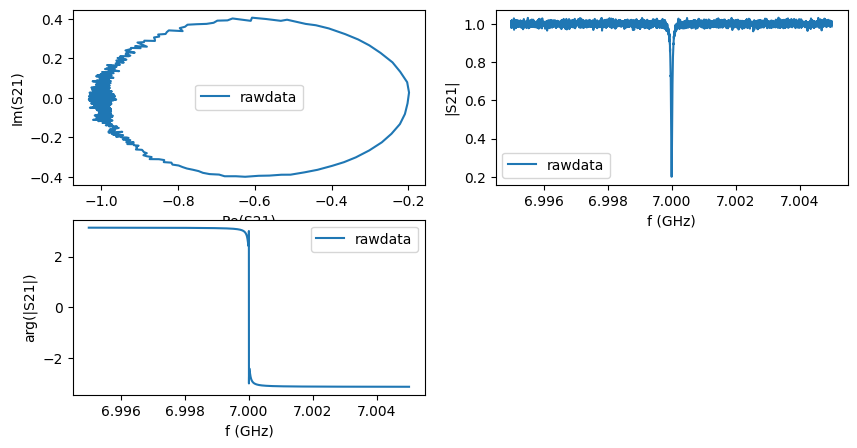

In [3]:
plt.rcParams["figure.figsize"] = [10,5]
port1.plotrawdata()

...and fit it: (since we know the electric delay, we tell it the program, this makes it more accurate)

In [4]:
port1.autofit(electric_delay=0.)

...and plot the result:

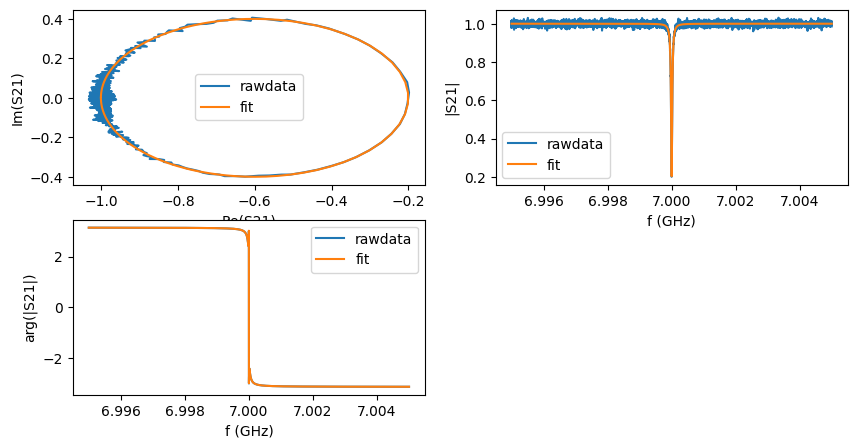

In [5]:
port1.plotall()

Next, let us have a look at the fit results. Here, we convert the dictionary of results into a dataframe to display it in a nicer way.

In [6]:
# display(pd.DataFrame([port1.fitresults]).applymap(lambda x: "{0:.2e}".format(x)))

## 2. Wavy Baseline

Remember to think before removing a baseline if it is justified to do that!

Generate some low frequency signals:

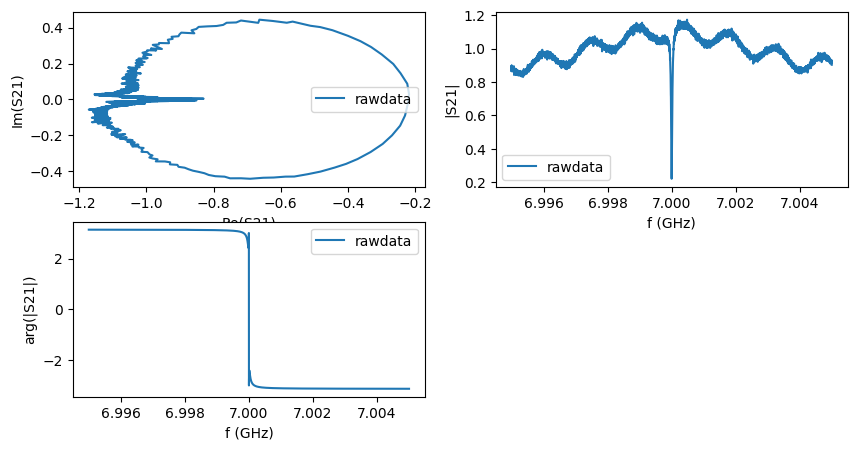

In [7]:
baseline = 1+0.1*np.cos(2.*np.pi*0.001e-4*freq)+0.05*np.sin(2.*np.pi*0.0069e-4*freq)+0.001*np.sin(2.*np.pi*0.0001e-4*freq)
S11b = port1.z_data*baseline
port2 = circuit.reflection_port() 
port2.add_data(freq,S11b)
port2.plotrawdata()

Here, the problem is clearly in the amplitude signal. The following procedure would also work for the phase signal:

        see http://zanran_storage.s3.amazonaws.com/www.science.uva.nl/ContentPages/443199618.pdf
        "Asymmetric Least Squares Smoothing" by P. Eilers and H. Boelens in 2005.
        http://stackoverflow.com/questions/29156532/python-baseline-correction-library
        "There are two parameters: p for asymmetry and lambda for smoothness. Both have to be
        tuned to the data at hand. We found that generally 0.001<=p<=0.1 is a good choice
        (for a signal with positive peaks) and 10e2<=lambda<=10e9, but exceptions may occur."

In [8]:
from resonator_tools import calibration

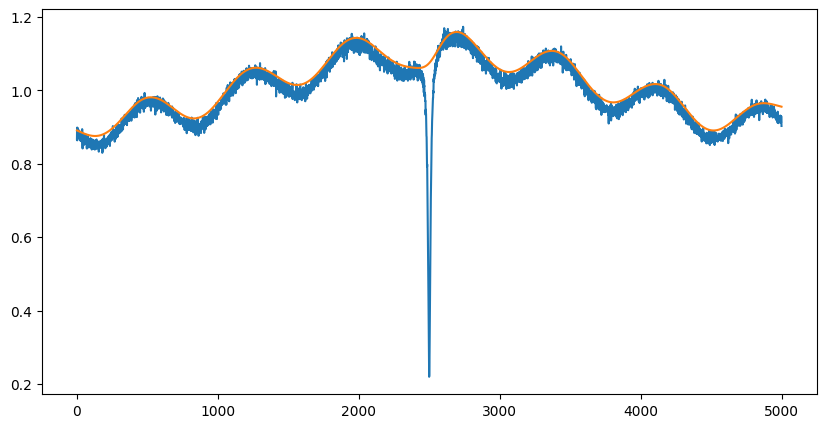

In [9]:
lam = 1e6#smoothness
p = 0.99  #asymmetry
fitted_baseline = port2.fit_baseline_amp(port2.z_data_raw,lam,p,niter=10)
plt.plot(np.absolute(port2.z_data_raw))
plt.plot(fitted_baseline)

The computed baseline marks the upper bound of the data. We need to shift it manually a bit such that it is in the middle of the noise.

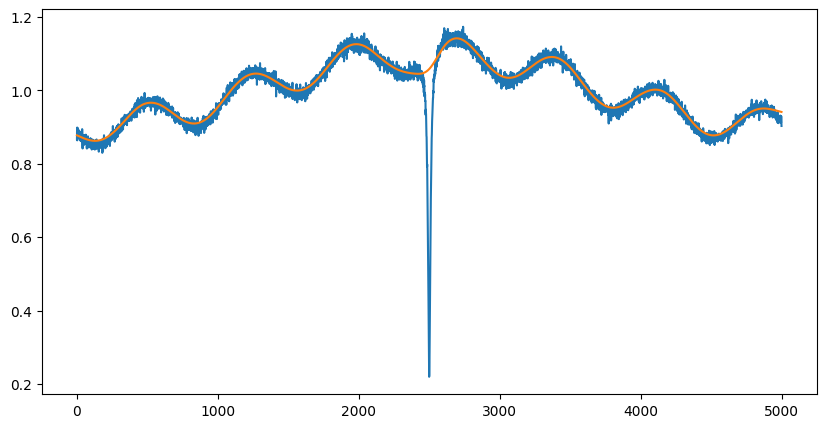

In [10]:
base_correct = 0.985
plt.plot(np.absolute(port2.z_data_raw))
plt.plot(fitted_baseline*base_correct)

Now we normalize and fit and plot everything. Cutting the data around the resonance for the final fit helps a lot:

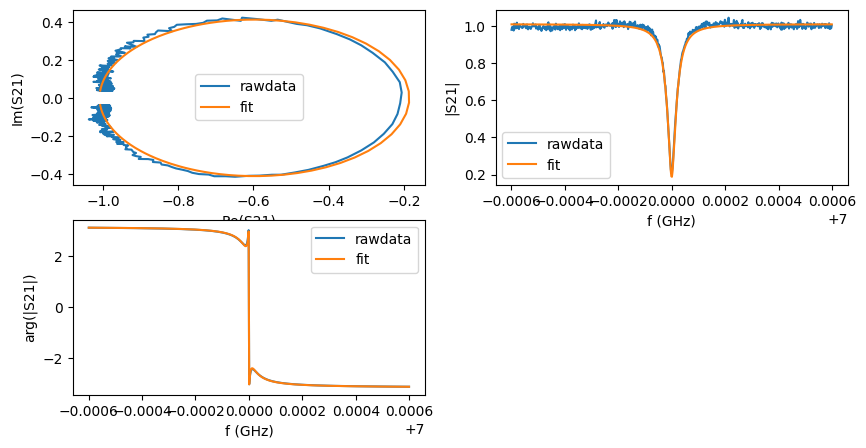

In [11]:
port3 = circuit.reflection_port() 
port3.add_data(freq[2200:2800],(S11b/(fitted_baseline*base_correct))[2200:2800])
port3.autofit(electric_delay=0.)
port3.plotall()

Below, the comparison of the data fitted without(row 0) wiggly baseline and after adding and removing the basline (row 1).

In [12]:
# display(pd.DataFrame([port1.fitresults,port3.fitresults]).applymap(lambda x: "{0:.2e}".format(x)))

# My data

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resonator_tools import circuit
from IPython.display import display
%matplotlib inline


from _example_setup import data_path, ensure_repo_root_on_path
ensure_repo_root_on_path()

port1 = circuit.reflection_port()  #define a reflection port
port1.add_froms2p(
    str(data_path("s2210dBmm.s1p")), 1, 2, "realimag", fdata_unit=1e9, delimiter=None
)


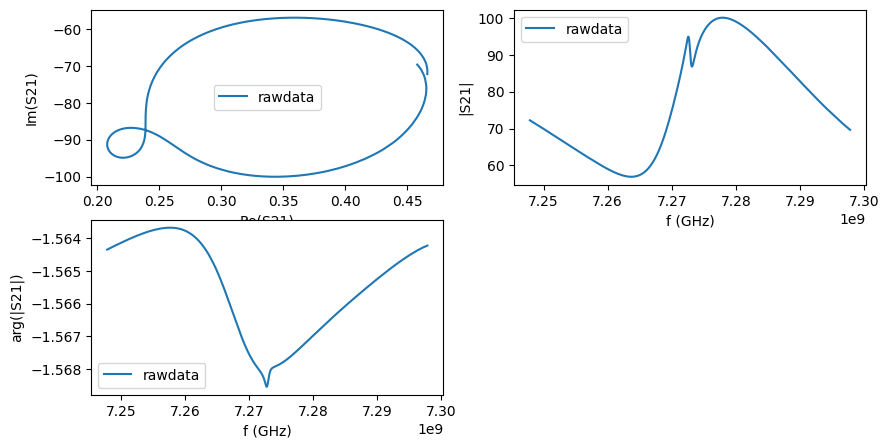

In [71]:
plt.rcParams["figure.figsize"] = [10,5] 
port1.plotrawdata()

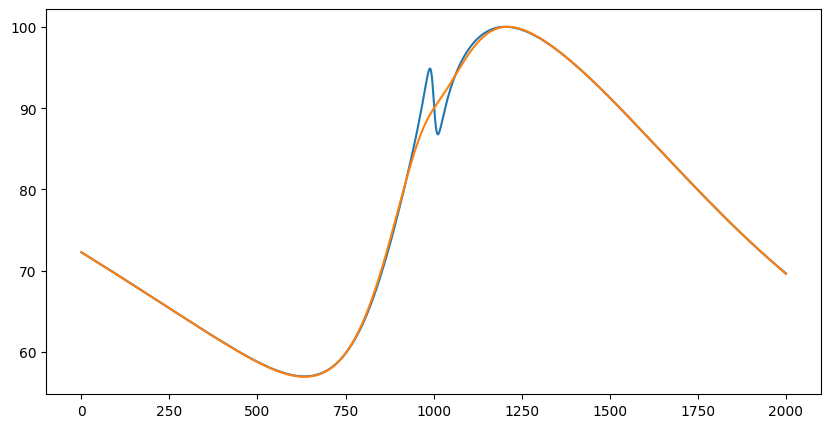

In [65]:
lam = 1e6#smoothness
p = 0.4 #asymmetry

fitted_baseline = port1.fit_baseline_amp(port1.z_data_raw,lam,p,niter=10)
plt.plot(np.absolute(port1.z_data_raw))
plt.plot(fitted_baseline)

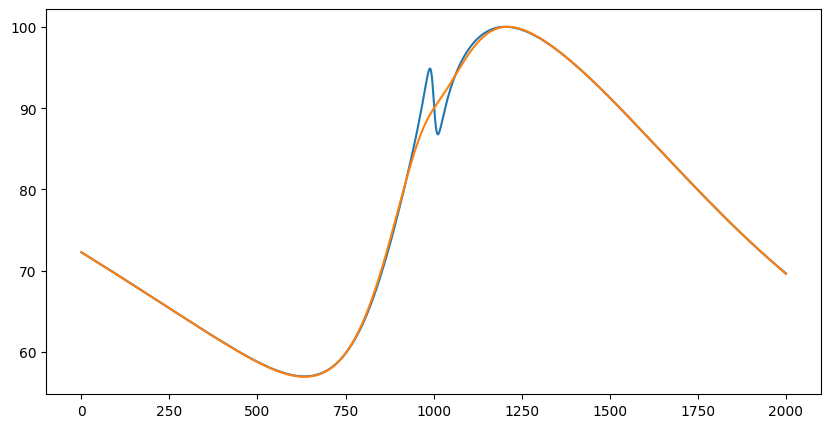

In [66]:
base_correct = 1 # 0.985
plt.plot(np.absolute(port1.z_data_raw))
plt.plot(fitted_baseline*base_correct)

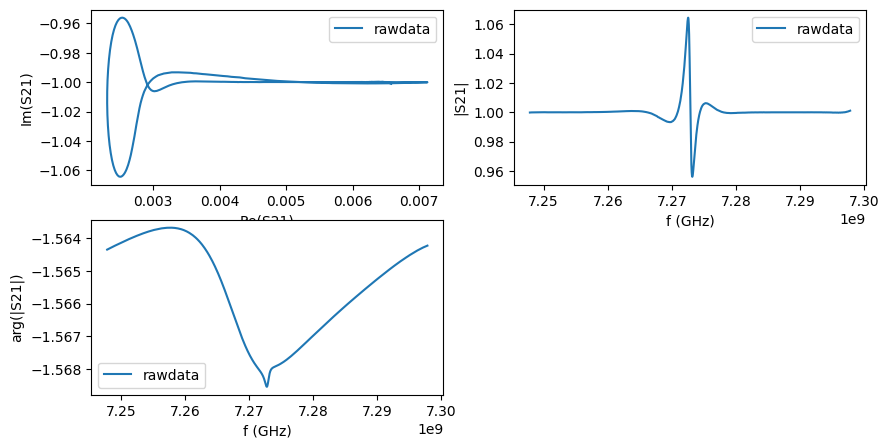

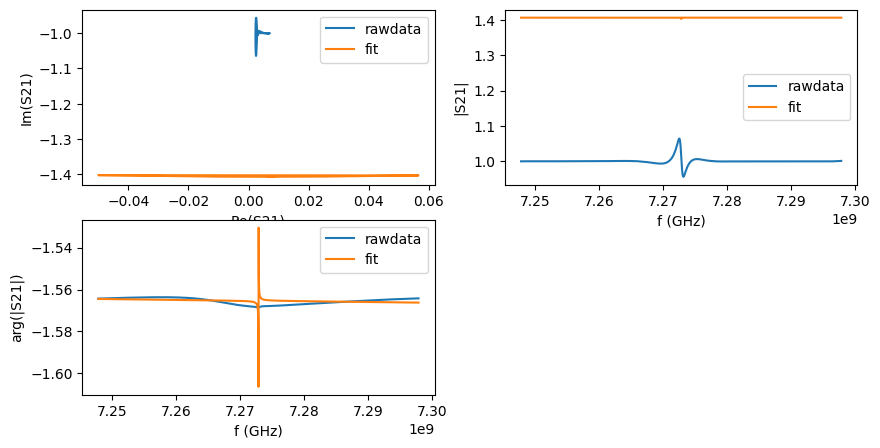

In [67]:
port3 = circuit.reflection_port()

# start = 7.2715e+18
# end = 7.2745e+18
# port3.cut_data( start, end )
# port3.plotrawdata()

start = 0
end = -1
# start = 900
# end = 1150
# start = 950
# end = 1080

base_correct = 1.0

freq = port1.f_data
S11 = port1.z_data_raw
port3.add_data(freq[start:end],(S11/(fitted_baseline*base_correct))[start:end])
port3.plotrawdata()
port3.autofit()
port3.plotall()


## Baseline correction by initial circle fit


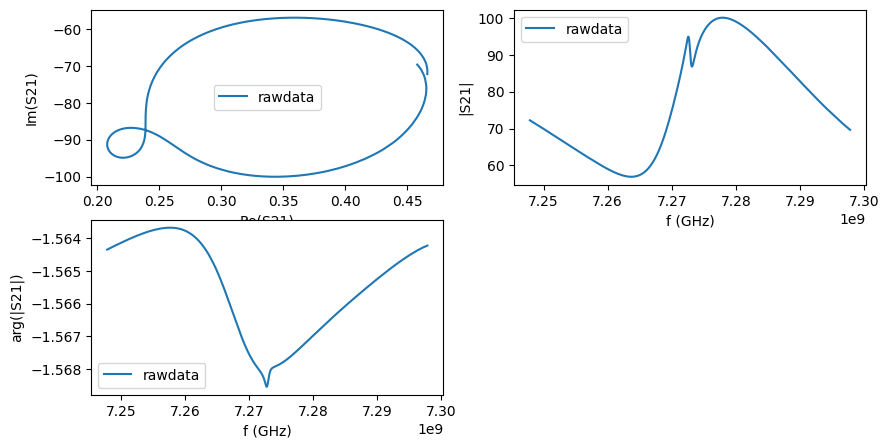

In [72]:
port1.plotrawdata()

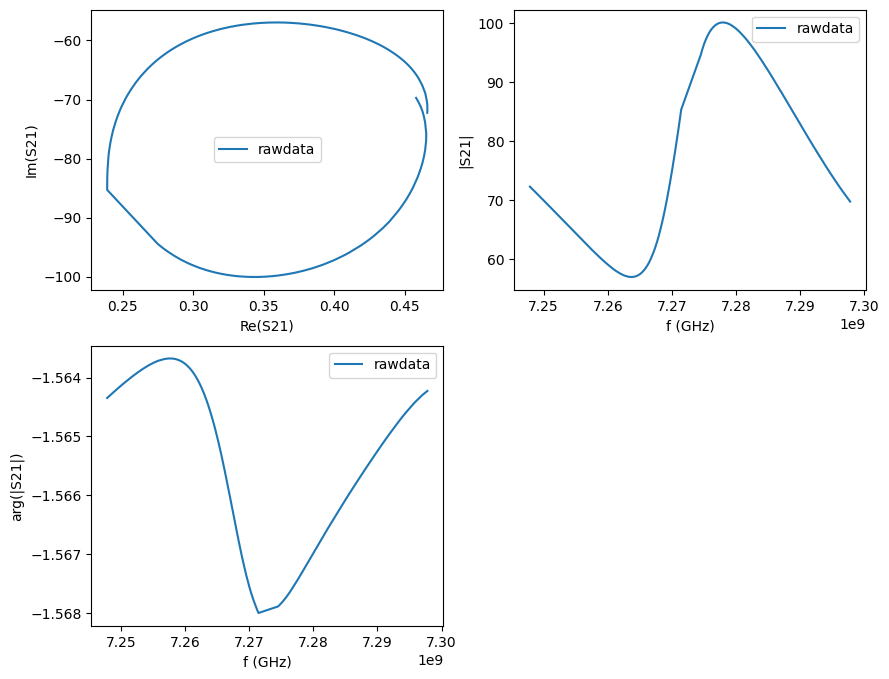

/opt/anaconda3/envs/resonator-tools/lib/python3.11/site-packages/resonator_tools/circlefit.py:157: RuntimeWarning: Number of calls to function has reached maxfev = 800.
  p_final = spopt.leastsq(


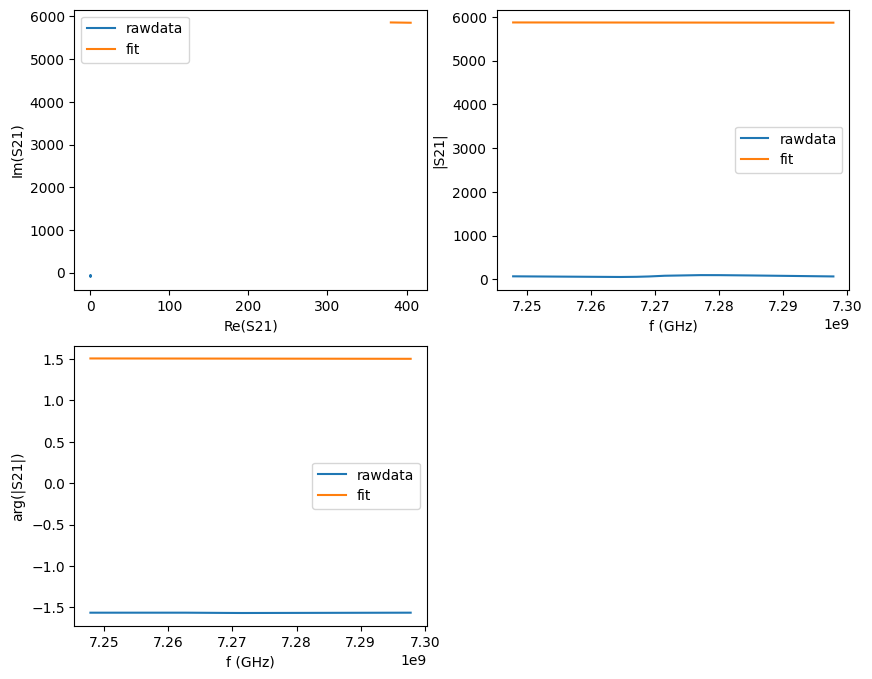

In [89]:
plt.rcParams["figure.figsize"] = [10,8] 

port4 = circuit.reflection_port()
port5 = circuit.reflection_port()
freq = port1.f_data
S11  = port1.z_data_raw
port4.add_data( freq, S11 ) 
port5.add_data( freq, S11 ) 

mask_start = 7.2715e+18
mask_end = 7.2745e+18
port4.cut_data( freq[0], start )
port5.cut_data( end, freq[-1] )
port4.add_data( np.concatenate([port4.f_data, port5.f_data]), np.concatenate([port4.z_data_raw, port5.z_data_raw]))

port4.plotrawdata()

# freq = port1.f_data
# S11 = port1.z_data_raw
# port3.add_data(freq[start:end],(S11/(fitted_baseline*base_correct))[start:end])
# port3.plotrawdata()
port4.autofit()
port4.plotall()

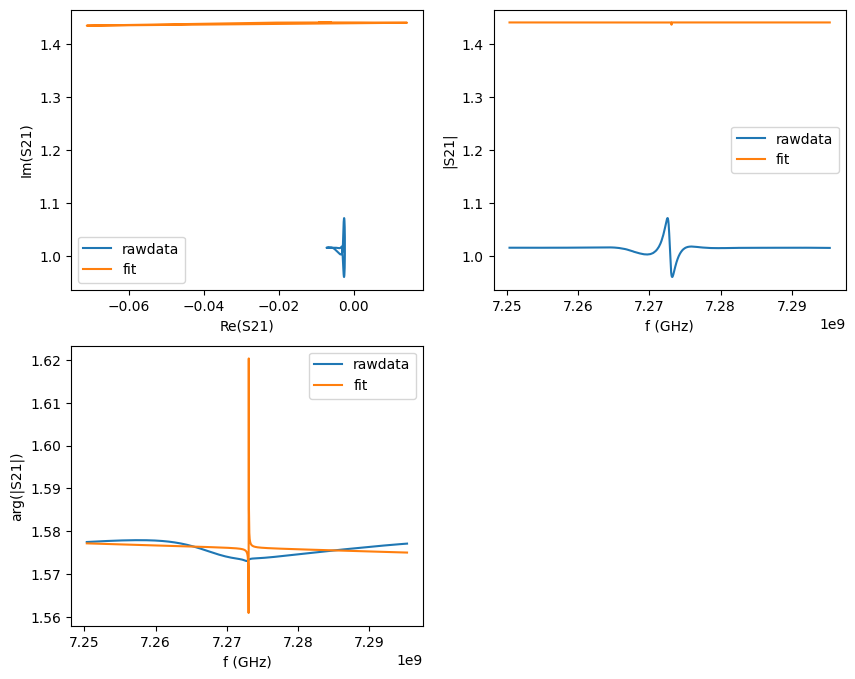

{'Qi': np.float64(8534751.83148038), 'Qc': np.float64(25679479.079896934), 'Ql': np.float64(6405755.011015963), 'fr': np.float64(7.27309363784549e+18), 'theta0': np.float64(1.5860321750708293), 'Ql_err': np.float64(53326753820.52469), 'Qc_err': np.float64(87658996202.82274), 'fr_err': np.float64(1684416338665709.8), 'chi_square': np.float64(0.08776103382110606), 'Qi_err': np.float64(104333053065.45975)}


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resonator_tools import circuit
%matplotlib inline

port_new = circuit.reflection_port()
port_new.add_froms2p(
    str(data_path("s2210dBmm.s1p")), 1, 2, "realimag", fdata_unit=1e9, delimiter=None
)
freq = port_new.f_data
S11 = port_new.z_data_raw

port_raw = circuit.reflection_port()
port_raw.add_data(freq, S11)

lam_amp = 1e6
lam_phase = 1e7
p_amp = 0.75
p_phase = 0.5

# 共振近傍をマスク
mask = np.ones_like(freq, dtype=bool)
mask[970:1030] = False

amp = np.abs(S11)
phase = np.unwrap(np.angle(S11))

# baseline作成用の配列を補間で埋める
amp_for_base = amp.copy()
phase_for_base = phase.copy()

amp_for_base[~mask] = np.interp(freq[~mask], freq[mask], amp[mask])
phase_for_base[~mask] = np.interp(freq[~mask], freq[mask], phase[mask])

baseline_amp = port_raw.fit_baseline_amp(amp_for_base, lam_amp, p_amp, niter=10)
baseline_phase = port_raw.fit_baseline_phase(phase_for_base, lam_phase, p_phase, niter=10)

base_correct = 0.985
baseline_amp_corr = baseline_amp * base_correct

S11_corr = (amp / baseline_amp_corr) * np.exp(1j * (phase - baseline_phase))

start = 100
end = 1900
freq_fit = freq[start:end]
S11_fit = S11_corr[start:end]

port_fit = circuit.reflection_port()
#port_fit = circuit.notch_port()
port_fit.add_data(freq_fit, S11_fit)

port_fit.autofit()   # delayも自動で最適化

port_fit.plotall()
print(port_fit.fitresults)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

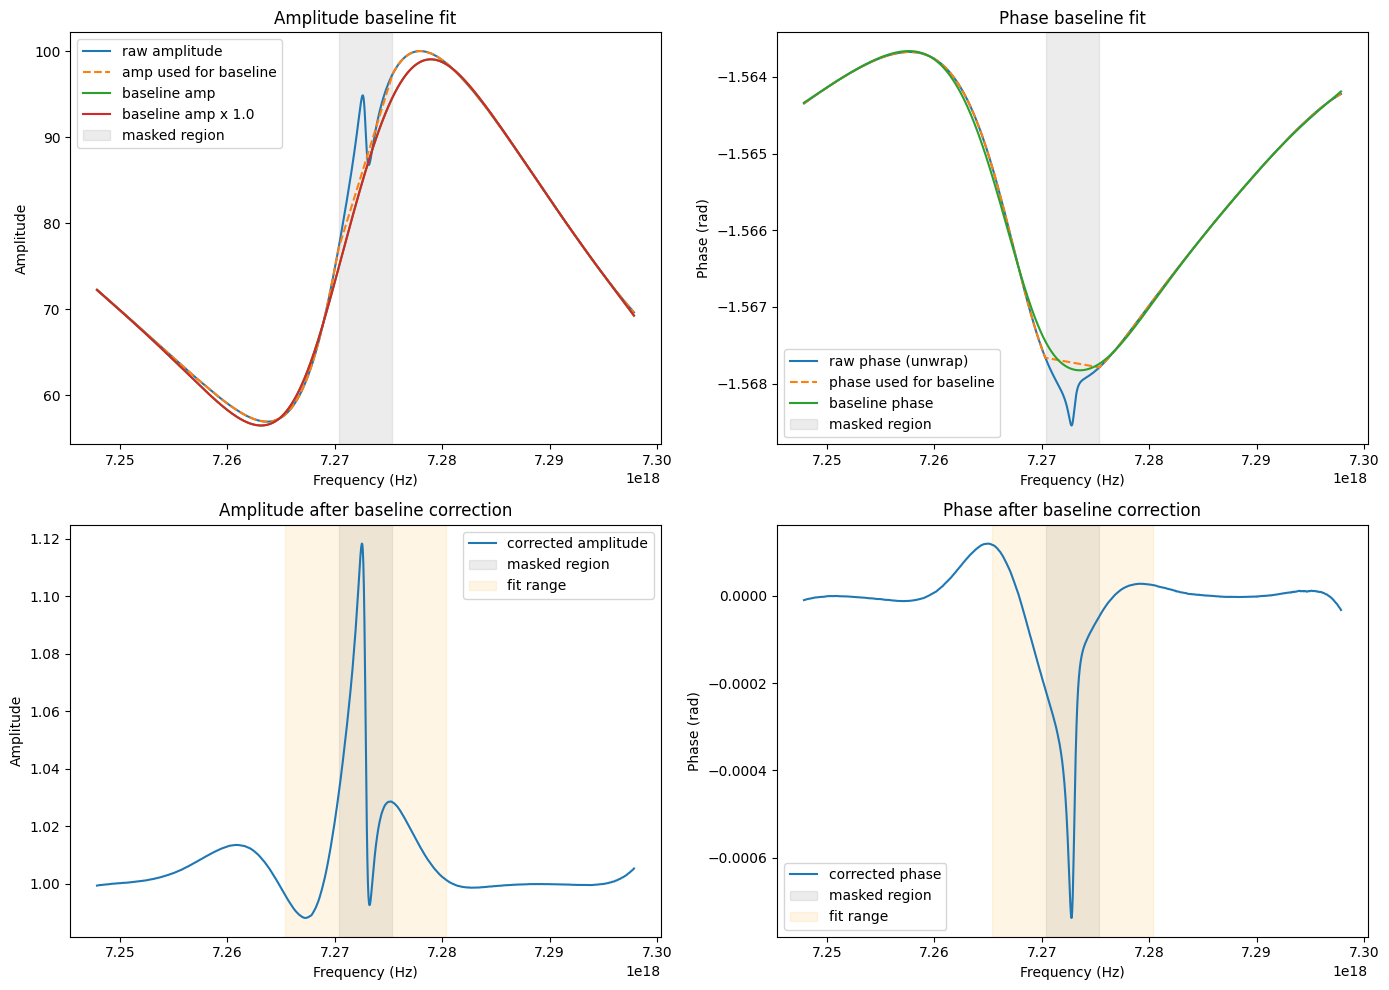

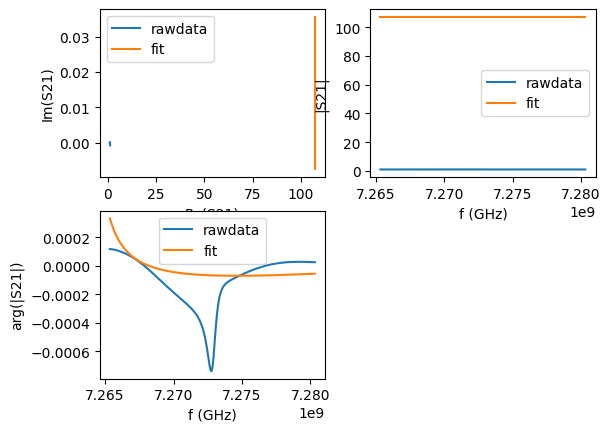

{'Qi': np.float64(8141177.716454145), 'Qc': np.float64(8141878.489830066), 'Ql': np.float64(4070764.044031262), 'fr': np.float64(7.26373833622823e+18), 'theta0': np.float64(1.5656179510702704), 'Ql_err': np.float64(1812014694479875.2), 'Qc_err': np.float64(1809854869849809.0), 'fr_err': np.float64(98429245.08398546), 'chi_square': np.float64(0.9860153842489672), 'Qi_err': np.float64(9056976537190990.0)}
===== settings summary =====


NameError: name 'path' is not defined

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resonator_tools import circuit
import itertools
import copy
from tqdm.notebook import tqdm
from tqdm.contrib.itertools import product
%matplotlib inline

from _example_setup import data_path, ensure_repo_root_on_path
ensure_repo_root_on_path()

# =========================================
# settings ここだけ主に編集
# =========================================

"""
see http://zanran_storage.s3.amazonaws.com/www.science.uva.nl/ContentPages/443199618.pdf
"Asymmetric Least Squares Smoothing" by P. Eilers and H. Boelens in 2005.
http://stackoverflow.com/questions/29156532/python-baseline-correction-library
"There are two parameters: p for asymmetry and lambda for smoothness. Both have to be
tuned to the data at hand. We found that generally 0.001<=p<=0.1 is a good choice
(for a signal with positive peaks) and 10e2<=lambda<=10e9, but exceptions may occur."
"""

# baseline parameters
niter = 10
# lambda (smoothness)
lam_amp_range = np.logspace(7, 9, 10) # 2, 9, 20
lam_phase_range = np.logspace(7, 9, 10) # 1, 10, 20
lam_amp = 1e6
lam_phase = 1e6
# p (asymmetry)
p_amp_range = np.logspace(-3, -1, 10)
p_phase_range = np.logspace(-4, 0, 10)
p_amp = 0.01 # 0.75
p_phase = 0.01 # 0.5

base_correct = 1.0 # 0.985

# fit type
use_notch_port = False   # True にすると notch_port, False で reflection_port

# ---- mask range の指定方法 ----
# method = "index" なら配列インデックスで指定
# method = "freq" なら周波数で指定
mask_method = "index"

# mask_method = "index" のとき使う
mask_start_idx = 900
mask_end_idx = 1100   # end は含まない

# mask_method = "freq" のとき使う
mask_fmin = 7.2727e9
mask_fmax = 7.2731e9

# ---- fit range の指定方法 ----
fit_method = "index"

# fit_method = "index" のとき使う
fit_start_idx = 700
fit_end_idx = 1300    # end は含まない

# fit_method = "freq" のとき使う
fit_fmin = 7.2715e9
fit_fmax = 7.2742e9


# =========================================
# load data
# =========================================
port_new = circuit.reflection_port()
port_new.add_froms2p(
    str(data_path("s2210dBmm.s1p")), 1, 2, "realimag", fdata_unit=1e9, delimiter=None
)
freq = port_new.f_data
S11 = port_new.z_data_raw

amp = np.abs(S11)
phase = np.unwrap(np.angle(S11))

port_raw = circuit.reflection_port()
port_raw.add_data(freq, S11)


# =========================================
# make mask
# =========================================
if mask_method == "index":
    mask = np.ones_like(freq, dtype=bool)
    mask[mask_start_idx:mask_end_idx] = False

elif mask_method == "freq":
    mask = (freq < mask_fmin) | (freq > mask_fmax)

else:
    raise ValueError("mask_method must be 'index' or 'freq'")


# =========================================
# baseline用データ作成
# =========================================
amp_for_base = amp.copy()
phase_for_base = phase.copy()
S11_for_base = S11.copy()

S11_for_base[~mask] = np.interp(freq[~mask], freq[mask], S11[mask])
amp_for_base[~mask] = np.interp(freq[~mask], freq[mask], amp[mask])
phase_for_base[~mask] = np.interp(freq[~mask], freq[mask], phase[mask])


# =========================================
# baseline fitting
# =========================================
amp_chi = 1e+6
phase_chi = 1e+6
baseline_amp = None

for lam_amp, p_amp in product(lam_amp_range, p_amp_range):
    baseline_amp_tmp = port_raw.fit_baseline_amp(amp_for_base, lam_amp, p_amp, niter=niter)
    amp_chi_tmp = np.sum((baseline_amp_tmp - amp_for_base)**2)
    if amp_chi_tmp < amp_chi:
        baseline_amp = baseline_amp_tmp.copy()
        amp_chi = copy.copy(amp_chi_tmp)
for lam_phase, p_phase in product(lam_phase_range, p_phase_range):
    # baseline_phase_tmp = port_raw.fit_baseline_phase(phase_for_base, lam_amp, p_amp, niter=niter)
    baseline_phase_tmp = port_raw.fit_baseline_phase(S11_for_base, lam_phase, p_phase, niter=niter)
    phase_chi_tmp = np.sum((baseline_phase_tmp - phase_for_base)**2)
    if phase_chi_tmp < phase_chi:
        baseline_phase = baseline_phase_tmp.copy()
        phase_chi = copy.copy(phase_chi_tmp)
# baseline_phase = port_raw.fit_baseline_phase(phase_for_base, lam_phase, p_phase, niter=niter)

baseline_amp_corr = baseline_amp * base_correct

S11_corr = (amp / baseline_amp_corr) * np.exp(1j * (phase - baseline_phase))


# =========================================
# fit range
# =========================================
if fit_method == "index":
    fit_slice = slice(fit_start_idx, fit_end_idx)
    freq_fit = freq[fit_slice]
    S11_fit = S11_corr[fit_slice]

elif fit_method == "freq":
    fit_sel = (freq >= fit_fmin) & (freq <= fit_fmax)
    freq_fit = freq[fit_sel]
    S11_fit = S11_corr[fit_sel]

else:
    raise ValueError("fit_method must be 'index' or 'freq'")


# =========================================
# resonator fit
# =========================================
if use_notch_port:
    port_fit = circuit.notch_port()
else:
    port_fit = circuit.reflection_port()

port_fit.add_data(freq_fit, S11_fit)
port_fit.autofit()


# =========================================
# plot helper for shaded ranges
# =========================================
f_mask_min = freq[~mask].min()
f_mask_max = freq[~mask].max()
f_fit_min = freq_fit.min()
f_fit_max = freq_fit.max()


# =========================================
# show baseline plots
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# raw amplitude + baseline
axes[0, 0].plot(freq, amp, label="raw amplitude")
axes[0, 0].plot(freq, amp_for_base, "--", label="amp used for baseline")
axes[0, 0].plot(freq, baseline_amp, label="baseline amp")
axes[0, 0].plot(freq, baseline_amp_corr, label=f"baseline amp x {base_correct}")
axes[0, 0].axvspan(f_mask_min, f_mask_max, alpha=0.15, color="gray", label="masked region")
axes[0, 0].set_title("Amplitude baseline fit")
axes[0, 0].set_xlabel("Frequency (Hz)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend()

# raw phase + baseline
axes[0, 1].plot(freq, phase, label="raw phase (unwrap)")
axes[0, 1].plot(freq, phase_for_base, "--", label="phase used for baseline")
axes[0, 1].plot(freq, baseline_phase, label="baseline phase")
axes[0, 1].axvspan(f_mask_min, f_mask_max, alpha=0.15, color="gray", label="masked region")
axes[0, 1].set_title("Phase baseline fit")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Phase (rad)")
axes[0, 1].legend()

# corrected amplitude
axes[1, 0].plot(freq, np.abs(S11_corr), label="corrected amplitude")
axes[1, 0].axvspan(f_mask_min, f_mask_max, alpha=0.15, color="gray", label="masked region")
axes[1, 0].axvspan(f_fit_min, f_fit_max, alpha=0.10, color="orange", label="fit range")
axes[1, 0].set_title("Amplitude after baseline correction")
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend()

# corrected phase
axes[1, 1].plot(freq, np.unwrap(np.angle(S11_corr)), label="corrected phase")
axes[1, 1].axvspan(f_mask_min, f_mask_max, alpha=0.15, color="gray", label="masked region")
axes[1, 1].axvspan(f_fit_min, f_fit_max, alpha=0.10, color="orange", label="fit range")
axes[1, 1].set_title("Phase after baseline correction")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Phase (rad)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# =========================================
# show fit result
# =========================================
port_fit.plotall()
print(port_fit.fitresults)


# =========================================
# print settings summary
# =========================================
print("===== settings summary =====")
print(f"path           = {path}")
print(f"use_notch_port = {use_notch_port}")
print(f"lam_amp        = {lam_amp}")
print(f"lam_phase      = {lam_phase}")
print(f"p_amp          = {p_amp}")
print(f"p_phase        = {p_phase}")
print(f"base_correct   = {base_correct}")

if mask_method == "index":
    print(f"mask_method     = index")
    print(f"mask_start_idx  = {mask_start_idx}")
    print(f"mask_end_idx    = {mask_end_idx}")
else:
    print(f"mask_method     = freq")
    print(f"mask_fmin       = {mask_fmin}")
    print(f"mask_fmax       = {mask_fmax}")

if fit_method == "index":
    print(f"fit_method      = index")
    print(f"fit_start_idx   = {fit_start_idx}")
    print(f"fit_end_idx     = {fit_end_idx}")
else:
    print(f"fit_method      = freq")
    print(f"fit_fmin        = {fit_fmin}")
    print(f"fit_fmax        = {fit_fmax}")